In [1]:
import gc
import math

import torchvision
from PIL import Image
from accelerate import Accelerator
from datasets import Dataset
from matplotlib import pyplot as plt
from torch import nn
from torch.optim.lr_scheduler import LinearLR
from torchvision.transforms import transforms
from tqdm import tqdm
import torch
from diffusers import UNet2DModel, DDIMScheduler, DDPMScheduler

In [2]:
IMAGE_SIZE = 256
VECTOR_SIZE = 39
CLASS_EMB_SIZE = 16
MODEL_ID = "google/ddpm-celebahq-256"
DEVICE = "cuda"

N_EPOCHS = 2
BS = 1
gradient_accumulation_steps = 2

## Dataloader

In [3]:
dataset = Dataset.load_from_disk("../dataset/CelebA/celeba_vectors")

In [4]:
h = math.ceil(218 * (IMAGE_SIZE / 178))

preprocess = transforms.Compose(
    [
        transforms.Resize((h, IMAGE_SIZE)),
        transforms.CenterCrop((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.5], [0.5]),
    ]
)


def transform(examples):
    images = [
        preprocess(Image.open(f"../dataset/CelebA/img_align_celeba/{image}"))
        for image in examples["images"]
    ]
    return {"images": images, "vectors": torch.FloatTensor(examples["vectors"])}

Previewing batch:


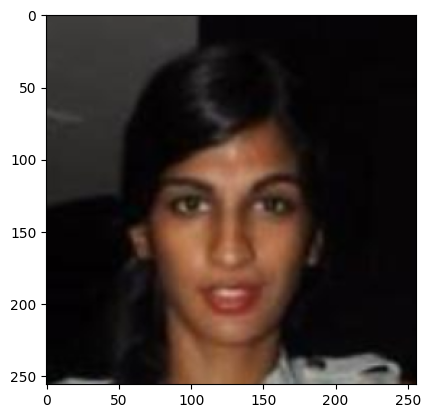

In [5]:
dataset.set_transform(transform)

train_dataloader = torch.utils.data.DataLoader(
    dataset, batch_size=BS, shuffle=True
)

print("Previewing batch:")
batch = next(iter(train_dataloader))
grid = torchvision.utils.make_grid(batch["images"], nrow=4)
plt.imshow(grid.permute(1, 2, 0).cpu().clip(-1, 1) * 0.5 + 0.5);

In [23]:
print(batch["images"].shape, batch["vectors"].shape)

torch.Size([4, 3, 256, 256]) torch.Size([4, 39])


## Unet

In [6]:
class ConditionedUnet(nn.Module):
    """
    https://huggingface.co/learn/diffusion-course/unit2/3
    """
    def __init__(
            self, 
            img_size=IMAGE_SIZE,
            num_classes=VECTOR_SIZE, 
            class_emb_size=CLASS_EMB_SIZE
    ):
        super().__init__()

        self.class_emb = nn.Sequential(
            nn.Dropout(0.2),
            nn.Linear(num_classes, class_emb_size),
            nn.SiLU()
        )
        self.add_cond = nn.Conv2d(3+class_emb_size, 3, kernel_size=1)            
        self.model = UNet2DModel(
            act_fn="silu",
            attention_head_dim=None,
            block_out_channels=(128, 128, 256, 256, 512, 512),
            center_input_sample=False,
            down_block_types=(
                "DownBlock2D",
                "DownBlock2D",
                "DownBlock2D",
                "DownBlock2D",
                "AttnDownBlock2D",
                "DownBlock2D",
            ),
            downsample_padding=0,
            flip_sin_to_cos=False,
            freq_shift=1,
            in_channels=3,
            layers_per_block=2,
            mid_block_scale_factor=1,
            norm_eps=1e-06,
            norm_num_groups=32,
            out_channels=3,
            sample_size=img_size,
            time_embedding_type="positional",
            up_block_types=(
                "UpBlock2D",
                "AttnUpBlock2D",
                "UpBlock2D",
                "UpBlock2D",
                "UpBlock2D",
                "UpBlock2D"
            ),
        )

    def forward(self, x, t, vectors=None):
        bs, ch, w, h = x.shape
        
        if vectors is not None:
            class_cond = self.class_emb(vectors)
            # (bs x 16)
            class_cond = class_cond.view(bs, class_cond.shape[1], 1, 1) \
                .expand(bs, class_cond.shape[1], w, h)
            # x is shape (bs, 3, 256, 256) and class_cond is now (bs, 16, 256, 256)
    
            net_input = torch.cat((x, class_cond), 1)  # (bs, 18, 256, 256)
            x = self.add_cond(net_input)

        # Feed this to the UNet alongside the timestep and return the prediction
        return self.model(x, t).sample  # (bs, 3, 256, 256)
    
    def init_weights(self, unet_state_dict):
        self.model.load_state_dict(unet_state_dict, strict=True)

In [7]:
cond_unet = ConditionedUnet()

state_dict = torch.load(
    "/media/alex/Elements/My_projects/video_generation/backend/weights/ddpm-celebahq-256/unet.pth"
)
cond_unet.init_weights(state_dict)
cond_unet = cond_unet.to(DEVICE)

#### Check

0it [00:00, ?it/s]

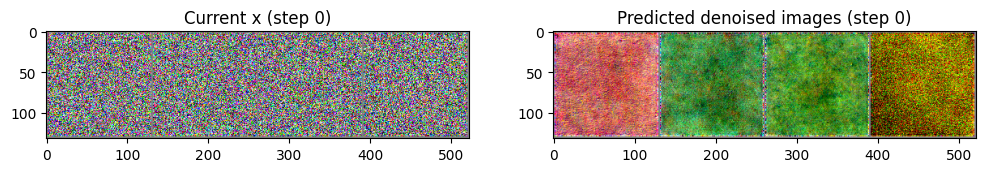

10it [00:01,  6.21it/s]

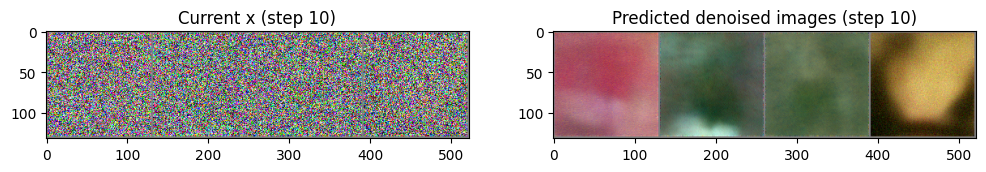

20it [00:03,  6.08it/s]

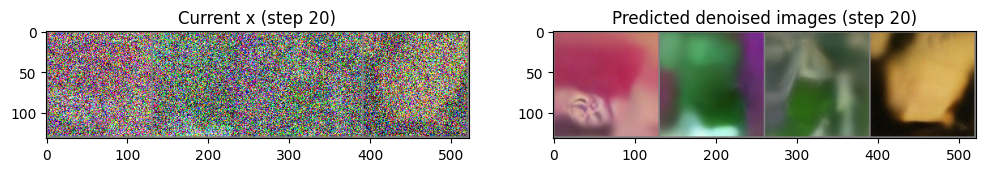

30it [00:05,  6.06it/s]

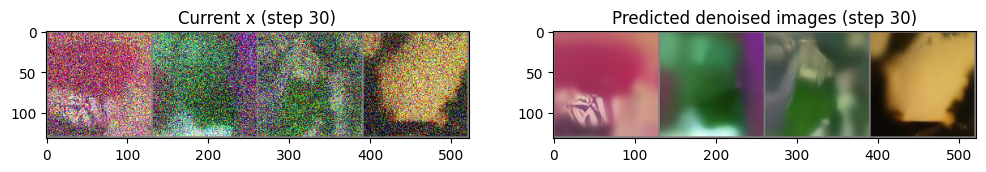

39it [00:06,  6.01it/s]

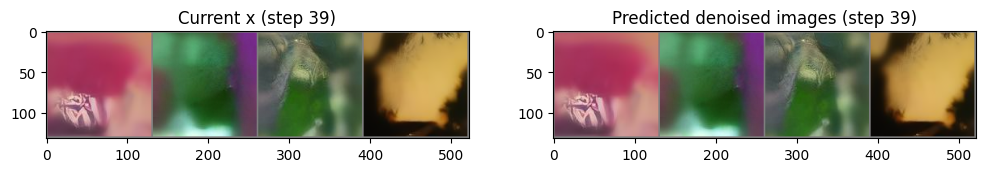

40it [00:07,  5.45it/s]


In [17]:
# unet = UNet2DModel.from_pretrained(MODEL_ID).to(DEVICE)
unet = cond_unet
scheduler = DDIMScheduler.from_pretrained(MODEL_ID)
scheduler.set_timesteps(num_inference_steps=40)

x = torch.randn(4, 3, IMAGE_SIZE, IMAGE_SIZE).to(DEVICE)

# Loop through the sampling timesteps
for i, t in tqdm(enumerate(scheduler.timesteps)):

    # Prepare model input
    model_input = scheduler.scale_model_input(x, t)

    # Get the prediction
    with torch.no_grad():
        noise_pred = unet(model_input, t)

    # Calculate what the updated sample should look like with the scheduler
    scheduler_output = scheduler.step(noise_pred, t, x)

    # Update x
    x = scheduler_output.prev_sample

    # Occasionally display both x and the predicted denoised images
    if i % 10 == 0 or i == len(scheduler.timesteps) - 1:
        fig, axs = plt.subplots(1, 2, figsize=(12, 5))

        grid = torchvision.utils.make_grid(x, nrow=4).permute(1, 2, 0)
        axs[0].imshow(grid.cpu().clip(-1, 1) * 0.5 + 0.5)
        axs[0].set_title(f"Current x (step {i})")

        pred_x0 = (
            scheduler_output.pred_original_sample
        )  # Not available for all schedulers
        grid = torchvision.utils.make_grid(pred_x0, nrow=4).permute(1, 2, 0)
        axs[1].imshow(grid.cpu().clip(-1, 1) * 0.5 + 0.5)
        axs[1].set_title(f"Predicted denoised images (step {i})")
        plt.show()

## Train

In [8]:
noise_scheduler = DDPMScheduler(
      beta_end=0.02,
      beta_schedule="linear",
      beta_start=0.0001,
      clip_sample=True,
      num_train_timesteps=1000,
      trained_betas=None,
      variance_type="fixed_small"
)
loss_fn = nn.MSELoss()
opt = torch.optim.Adam(cond_unet.parameters(), lr=1e-3)
lr_scheduler = LinearLR(opt)

In [9]:
model=cond_unet
device=DEVICE
dataloader=train_dataloader
optimizer=opt
criterion=loss_fn
n_epochs=N_EPOCHS
writer=None
losses = []

In [ ]:
for epoch in range(n_epochs):
    for index, batch in tqdm(enumerate(dataloader)):

        imgs = batch["images"].to(device)
        vecs = batch["vectors"].to(device)
        noise = torch.randn_like(imgs)
        timesteps = torch.randint(0, 999, (imgs.shape[0],)).long().to(device)
        noisy_img = noise_scheduler.add_noise(imgs, noise, timesteps)

        pred = model(noisy_img, timesteps, vecs)
        loss = criterion(pred, noise)

        loss.backward()

        # gradient_accumulation - все равно не помещается у меня на cuda   
        # if (index + 1) % gradient_accumulation_steps == 0:
        #     optimizer.step()
        #     optimizer.zero_grad()
        
        # Zero_grad лучше всего ставить именно
        # после step и до нового forward
        optimizer.step()
        optimizer.zero_grad()

        # Store the loss
        losses.append(loss.item())

    avg_loss = sum(losses[-1000:]) / 1000
    print(f"{epoch}: Average of the last 1000 loss values: {avg_loss:05f}")
    if writer is not None:
        writer.add_scalar('Loss/val', avg_loss, epoch)

7243it [1:29:14,  1.15it/s]

In [ ]:
props_dict = {
    "Изогнутые брови": {"pos": 0, "value": 1},    "Привлекательность": {"pos": 1, "value": 1},
    "Мешки под глазами": {"pos": 2, "value": 1},  "Лысый": {"pos": 3, "value": 1}, 
    "Челка": {"pos": 4, "value": 1},              "Большие губы": {"pos": 5, "value": 1}, 
    "Большой нос": {"pos": 6, "value": 1},        "Черные волосы": {"pos": 7, "value": 1}, 
    "Светлые волосы": {"pos": 8, "value": 1},     "Размытые": {"pos": 9, "value": 1}, 
    "Коричневые волосы": {"pos": 10, "value": 1}, "Густые брови": {"pos": 11, "value": 1},
    "Пухлость": {"pos": 12, "value": 1},          "Двойной подбородок": {"pos": 13, "value": 1}, 
    "Очки": {"pos": 14, "value": 1},              "Эспаньолка": {"pos": 15, "value": 1}, 
    "Седые волосы": {"pos": 16, "value": 1},      "Сильный макияж": {"pos": 17, "value": 1}, 
    "Высокие скулы": {"pos": 18, "value": 1},     "Мужчина": {"pos": 19, "value": 1}, 
    "Рот слегка открыт": {"pos": 20, "value": 1}, "Усы": {"pos": 21, "value": 1}, 
    "Узкие глаза": {"pos": 22, "value": 1},       "Без бороды": {"pos": 23, "value": 1}, 
    "Овальное лицо": {"pos": 24, "value": 1},     "Бледная кожа": {"pos": 25, "value": 1},
    "Острый нос": {"pos": 26, "value": 1},        "Залысины": {"pos": 27, "value": 1}, 
    "Розовые щеки": {"pos": 28, "value": 1},      "Бакенбарды": {"pos": 29, "value": 1},
    "Улыбчивость": {"pos": 30, "value": 1},       "Прямые волосы": {"pos": 31, "value": 1}, 
    "Волнистые волосы": {"pos": 32, "value": 1},  "В серьгах": {"pos": 33, "value": 1},
    "В шляпе": {"pos": 34, "value": 1},           "Губная помада": {"pos": 35, "value": 1}, 
    "Ожерелье": {"pos": 36, "value": 1},          "В галстуке": {"pos": 37, "value": 1}, 
    "Молодость": {"pos": 38, "value": 1},         "Прямые брови": {"pos": 0, "value": -1}, 
    "Узкие губы": {"pos": 5, "value": -1},        "Маленький нос": {"pos": 6, "value": -1},
    "Четкость": {"pos": 9, "value": -1},          "Редкие брови": {"pos": 11, "value": -1},
    "Стройность": {"pos": 12, "value": -1},       "Без макияжа": {"pos": 17, "value": -1}, 
    "Женщина": {"pos": 19, "value": -1},          "Широкие глаза": {"pos": 22, "value": -1},
    "Темная кожа": {"pos": 25, "value": -1},      "Грусть": {"pos": 30, "value": -1}, 
    "Старость": {"pos": 38, "value": -1}
}

#### Попытка с Accelerate

In [ ]:
accelerator = Accelerator(gradient_accumulation_steps=2)
model, optimizer, train_dataloader, lr_scheduler = accelerator.prepare(
    model, optimizer, train_dataloader, lr_scheduler
)

for epoch in range(n_epochs):
    for batch in train_dataloader:
        with accelerator.accumulate(model):
            imgs = batch["images"].to(device)
            vecs = batch["vectors"].to(device)
            noise = torch.randn_like(imgs)
            timesteps = torch.randint(0, 999, (imgs.shape[0],)).long().to(device)
            noisy_img = noise_scheduler.add_noise(imgs, noise, timesteps)
    
            pred = model(noisy_img, timesteps, vecs)
            loss = criterion(pred, noise)
    
            accelerator.backward(loss)        
            # Zero_grad лучше всего ставить именно
            # после step и до нового forward
            optimizer.step()
            print("step")
            lr_scheduler.step()
            optimizer.zero_grad()
    
            # Store the loss
            losses.append(loss.item())
    
    avg_loss = sum(losses[-50:]) / 50
    print(f"{epoch}: Average of the last 50 loss values: {avg_loss:05f}")
    if writer is not None:
        writer.add_scalar('Loss/val', avg_loss, epoch)